# Ridge Regression - Key Points

Adding something to the loss function to reduce the overfitting of your machine  learning model.

Understanding:

1) How do RR affect the coefficient (lambda can vary from 0 to +infinity) : At zero, it is simply linear regression. But as the lambda value increases, the coefficeints shrink close to zero but never becomes zero.

2) If the coefficients initally are on different levels (10, 100, 1000), so the larger ones will decrease faster towards zero compared to the smaller ones.

3) Affect of Regularisation on BIAS and VARIANCE - Regularisation was one of the three methods to improve the Bias-Variance Trade off. Initially if the model was overfit(the reason for introducing reg in the first place), the Bias is low but the Variance is high. Then as we increase the lambda, we compromise with the Bias but we improve on the Variance part. But as we increase the lambda too much, the model becomes underfit, the Bias itself is high and the Variance will reduce. We need Bias as well as Variance low.

4) Impact of lambda on the loss function: The loss function will be moving towards centre, this also explains why the values of the coefficient shrink towards 0.

5) Why called Ridge ? : We need to delve into Hard Constraint Ridge Regression. 

Use Ridge in the case when coef >= 2. It will not be of much help in the case of one input and one output.

Lets dive into each of the following points for a better understanding:

## 1. How are Coefficients Affected

In [9]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt

In [4]:
data = load_diabetes()
data

{'data': array([[ 0.03807591,  0.05068012,  0.06169621, ..., -0.00259226,
          0.01990749, -0.01764613],
        [-0.00188202, -0.04464164, -0.05147406, ..., -0.03949338,
         -0.06833155, -0.09220405],
        [ 0.08529891,  0.05068012,  0.04445121, ..., -0.00259226,
          0.00286131, -0.02593034],
        ...,
        [ 0.04170844,  0.05068012, -0.01590626, ..., -0.01107952,
         -0.04688253,  0.01549073],
        [-0.04547248, -0.04464164,  0.03906215, ...,  0.02655962,
          0.04452873, -0.02593034],
        [-0.04547248, -0.04464164, -0.0730303 , ..., -0.03949338,
         -0.00422151,  0.00306441]]),
 'target': array([151.,  75., 141., 206., 135.,  97., 138.,  63., 110., 310., 101.,
         69., 179., 185., 118., 171., 166., 144.,  97., 168.,  68.,  49.,
         68., 245., 184., 202., 137.,  85., 131., 283., 129.,  59., 341.,
         87.,  65., 102., 265., 276., 252.,  90., 100.,  55.,  61.,  92.,
        259.,  53., 190., 142.,  75., 142., 155., 225.,  59

In [6]:
df = pd.DataFrame(data.data, columns=data.feature_names)
df['Target'] = data.target
df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,Target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [7]:
X_train, X_test, y_train, y_test = train_test_split(data.data, data.target, test_size=0.2, random_state=2)

In [8]:
alphas = [0, 10, 100, 1000]
coefs = []
r2_scores = []

for i in alphas:
    reg = Ridge(alpha=i)
    reg.fit(X_train, y_train)
    y_pred = reg.predict(X_test)
    coefs.append(reg.coef_.tolist())
    r2_scores.append(r2_score(y_test, y_pred))

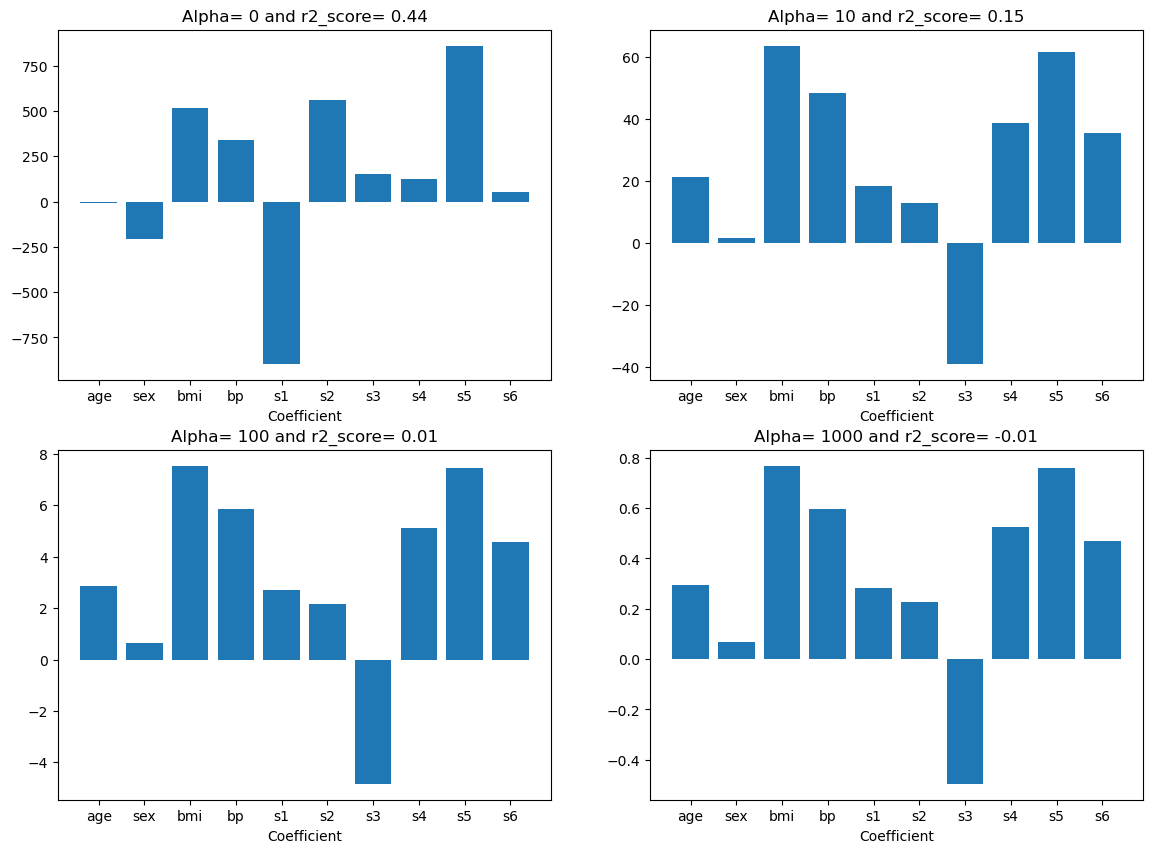

In [18]:
plt.figure(figsize=(14,10))

for i in range(4):
    plt.subplot(int(f"22{i+1}"))
    plt.bar(data.feature_names, coefs[i])
    plt.xlabel("Coefficient")
    plt.title(f"Alpha= {alphas[i]} and r2_score= {r2_scores[i]:.2f}")

plt.show()

See the values on the y axis, how are they shrinking towards zero, but they never attains zero value, also we can note that the coefficient with the highest values(which have the greatest impact on the result) changes the most in each operation

## 2. Higher Coefficients are affected more

In [41]:
alphas = [0, 0.001, 0.01, 0.1, 1, 10, 100, 1000, 10000]

coefs = []

for i in alphas:
    reg = Ridge(alpha = i)
    reg.fit(X_train, y_train)
    coefs.append(reg.coef_)

coef_arr = np.array(coefs)

df = pd.DataFrame(coef_arr, columns=data.feature_names)
df['alpha'] = alphas
df = df.set_index('alpha')

Again we can notice both the points discussed above, how the coefficients shrink towards zero and how the largest one shrink the fastest.

Lets plot these in the form of curves to get a feel.

In [42]:
df.shape

(9, 10)

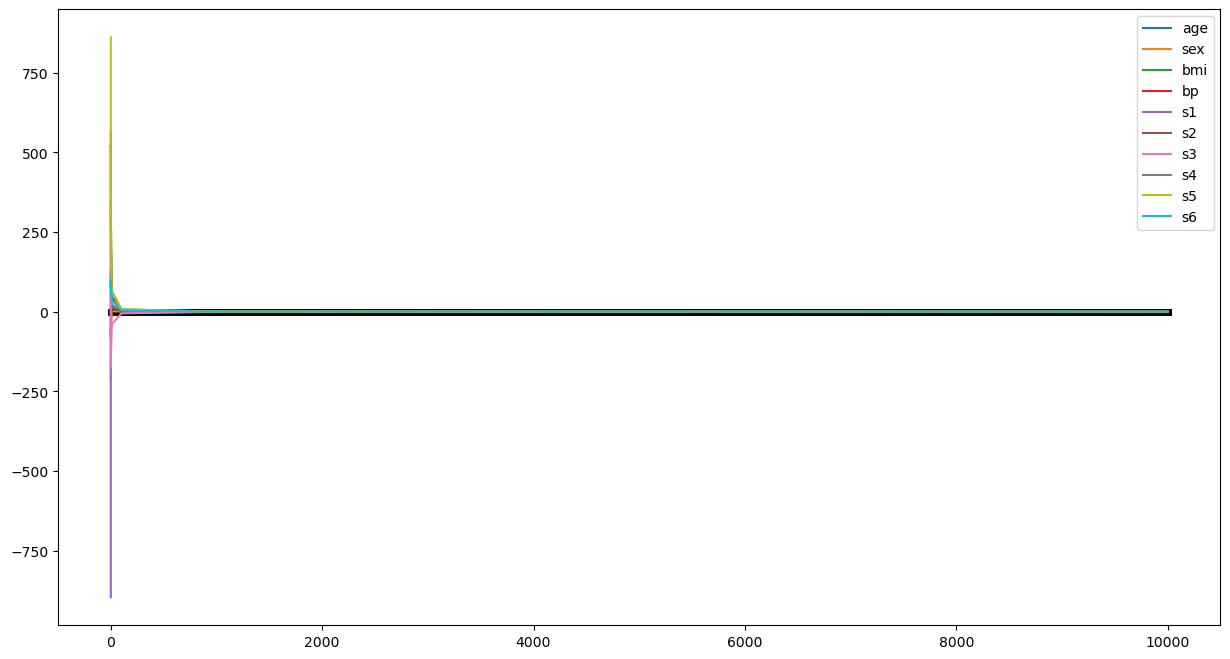

In [43]:
plt.figure(figsize=(15,8))
# lets plot a zero line
plt.plot(alphas, np.zeros(len(alphas)), color='black', linewidth = 5)
for i in range(df.shape[1]):
    plt.plot(alphas, df.iloc[:, i], label = data.feature_names[i])
plt.legend()
plt.show()

As we have a wide range of alphas here, and the value of coefficient drastically falls, these curves do not tell the story propperly.

We will take a closer range of alphas.

IndexError: list index out of range

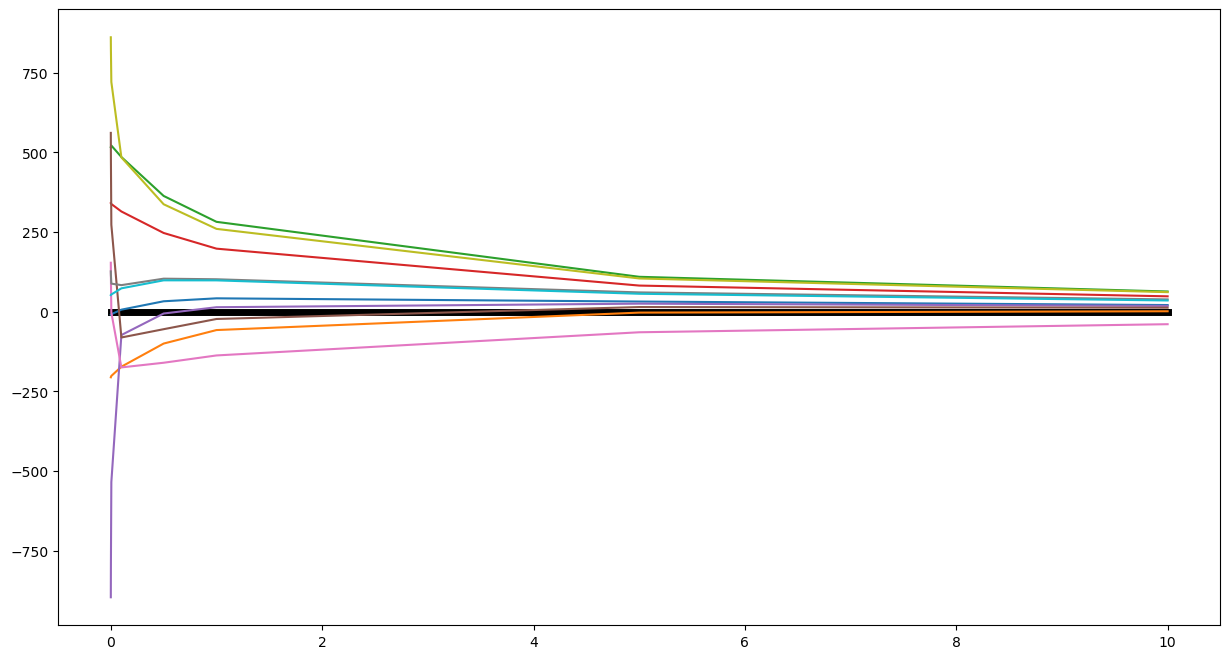

In [46]:
alphas = [0, 0.0001, 0.0005, 0.001, 0.005, 0.1, 0.5, 1, 5, 10]

coefs = []

for i in alphas:
    reg = Ridge(alpha=i)
    reg.fit(X_train, y_train)
    coefs.append(reg.coef_.tolist())

df = pd.DataFrame(np.array(coefs), columns = data.feature_names)
df['alpha'] = alphas
df.set_index('alpha')

plt.figure(figsize=(15,8))
plt.plot(alphas, np.zeros(len(alphas)), color = 'black', linewidth = 5)
for i in range(df.shape[1]):
    plt.plot(alphas, df.iloc[:, i], label = data.feature_names[i])

plt.legend()

Now this a better feel of both the points discussed till now.

## Impact on Bias and Variance

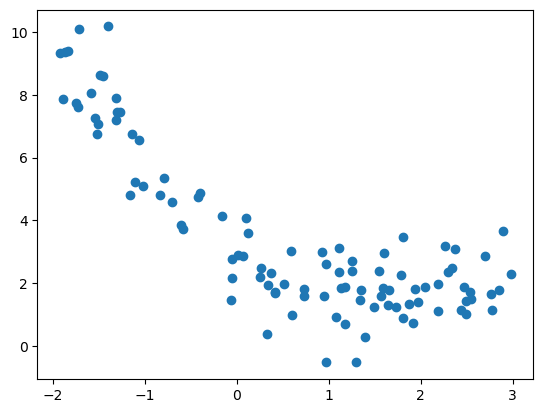

In [52]:
# lets make a data for ourselves
m = 100 # data points
X = 5 * np.random.rand(m,1) - 2
y = 0.7 * X ** 2 - 2 * X + 3 + np.random.randn(m,1)

plt.scatter(X,y)
plt.show()

In [53]:
X_train, X_test, y_train, y_test = train_test_split(X.reshape(100,1), y.reshape(100), test_size=0.2, random_state=4)

In [54]:
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree=15) # this will cause overfitting on a degree 2 data we have

X_train = poly.fit_transform(X_train)
X_test = poly.transform(X_test)

In [55]:
!pip install mlxtend
from mlxtend.evaluate import bias_variance_decomp

bias_variance_decomp helps you break down the sources of error(if your model suffers more from bias or variance) to improve your model’s performance. Useful for diagnosing underfitting vs overfitting beyond just looking at train/test accuracy.

In [56]:
alphas = np.linspace(0, 30, 100)

loss = []
bias = []
variance = []

for i in alphas:
    reg = Ridge(alpha = i)
    avg_expected_loss, avg_bias, avg_var = bias_variance_decomp(
        reg, X_train, y_train, X_test, y_test,
        loss = 'mse',
        random_seed=123)
    loss.append(avg_expected_loss)
    bias.append(avg_bias)
    variance.append(avg_var)

What did we do above:

1) Alphas evenly spread between 0 and 30 to see how the loss, bias and the variance changes.
2) We train Ridge regression on each alpha value.
3) bias_variance_decomp runs multiple train/test splits internally using bootstrap or random subsamples.
4) avg_expected_loss: average total error (mean squared error).
5) avg_bias: squared bias component of error (how far predictions on average are from the true function).
6) avg_var: variance component of error (how much predictions fluctuate across different training sets).

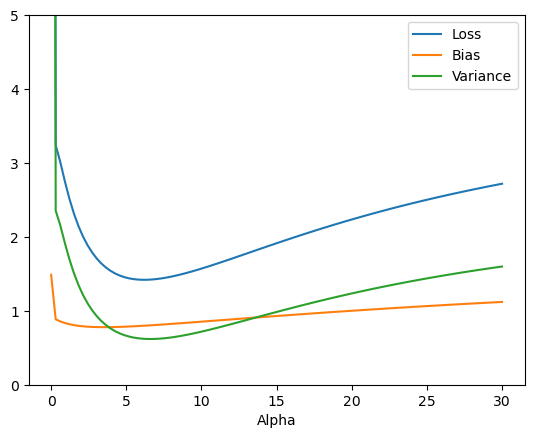

In [57]:
plt.plot(alphas, loss, label = 'Loss')
plt.plot(alphas, bias, label = 'Bias')
plt.plot(alphas, variance, label = 'Variance')
plt.ylim(0, 5)
plt.xlabel('Alpha')
plt.legend()

loss ≈ Bias² + Variance + Noise

We need to setle with an alpha that has low variance as well as low bias.

## Effect of Regularisation on Loss Function

Regularization adds a penalty term to the loss function to control model complexity. Its effects on the loss are:

1) Reduces overfitting by discouraging overly complex models (e.g., very large coefficients).

2) Increases bias but decreases variance:
    1) With stronger regularization, the model becomes simpler, so bias (error from wrong assumptions) may increase.
    2) Variance (error from sensitivity to training data noise) typically decreases.


3) The overall effect on the loss function (like MSE + penalty) is to balance fitting the data well and keeping the model coefficients small/smooth.

As we can see in the previous curve as well how the alphas effect loss function

[27.82809103]
-2.29474455867698


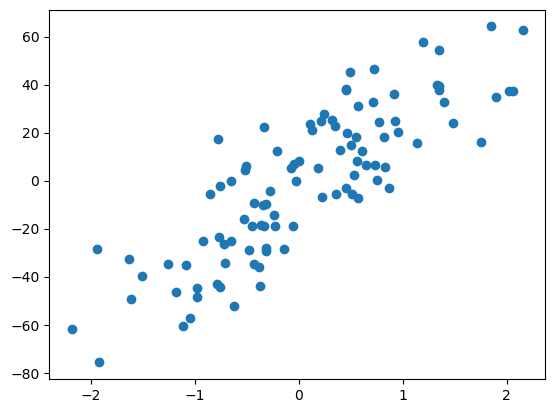

In [58]:
from sklearn.datasets import make_regression

X, y = make_regression(n_samples=100, n_features=1, n_informative=1, n_targets=1, noise = 20, random_state=13)

plt.scatter(X, y)

from sklearn.linear_model import LinearRegression

reg = LinearRegression()
reg.fit(X, y)
print(reg.coef_) # we will vary this slope
print(reg.intercept_) # we will use this intercet

In [61]:
def cal_loss(m, alpha):
    return np.sum((y - m * X.ravel() + 2.29) ** 2) + alpha * m * m  # this is the loss function after Regularisation

In [62]:
def predict(m):
    return m*X - 2.29 # We are varying the slope 'm' while keeping the intercept constant at -2.29

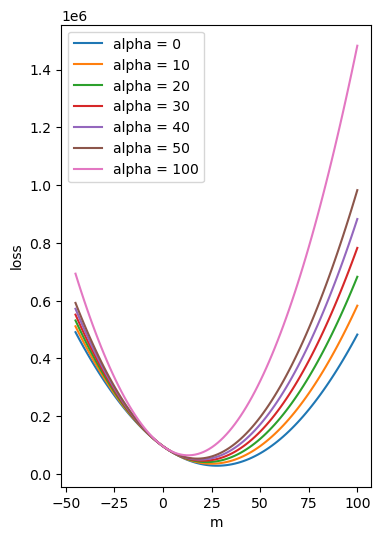

In [63]:
m = np.linspace(-45, 100, 100)
plt.figure(figsize=(4,6))

for j in [0,10,20,30,40,50,100]:
    loss = []
    for i in range(m.shape[0]):
        loss_i = cal_loss(m[i], j)
        loss.append(loss_i)
    plt.plot(m, loss, label = f'alpha = {j}')

plt.legend()
plt.xlabel('m') # we varying the slope keeping the intercept constant at 2.29
plt.ylabel('loss')
plt.show()

As we increasing the value of alpha(lambda), the value of the coefficients is moving towards zero(Here we have only a single input column, so a single slope)